In [7]:
import pandas as pd
import numpy as np

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)
file_name = "../data/processed/tac_co2_formatted_v2_label2.parquet"

In [8]:
df = pd.read_parquet(file_name)
df.head()

,date,time,type,sample,standard,port,co2_dry,co2_wet,co2_stdev,co2_std_rep,co2_std_stdev,co2_target_error,co2_Cdrift,co2_C,co2_N,co2_Nfiltered,cycle_time,h2o,h2o_stdev,cavity_press,cavity_press_stdev,cavity_temp,cavity_temp_stdev,das_temp,etalon_temp,warmbox_temp,outlet_valve,co2_flag,label2,datetime_str,datetime,year
0,120111,162730,unknown,-,USN-20112109,0,403.464,403.606,1.063,NaN,NaN,NaN,406.303,406.300,0,100.0,3.733,-0.02232,0.00175,140.00525,0.01396,44.90277,0.01251,32.14167,44.77072,NaN,31442.617,x,0,120111162730,2012-01-11 16:27:30,2012
1,120111,162830,unknown,-,USN-20112109,0,402.944,403.085,1.308,NaN,NaN,NaN,405.779,405.776,0,100.0,3.733,-0.02232,0.00170,140.00435,0.01518,44.92952,0.00415,32.36250,44.91882,NaN,31543.971,x,0,120111162830,2012-01-11 16:28:30,2012
2,120111,162930,unknown,-,USN-20112109,0,400.992,401.133,1.802,NaN,NaN,NaN,403.813,403.811,0,100.0,3.733,-0.02243,0.00221,140.00513,0.01176,44.93352,0.00128,32.59792,44.99702,NaN,31626.549,x,0,120111162930,2012-01-11 16:29:30,2012
3,120111,163030,unknown,-,USN-20112109,0,401.753,401.893,1.516,NaN,NaN,NaN,404.580,404.577,0,100.0,3.733,-0.02217,0.00256,140.00745,0.01437,44.92616,0.00253,32.81506,45.02549,NaN,31687.379,x,0,120111163030,2012-01-11 16:30:30,2012
4,120111,163130,unknown,-,USN-20112109,0,401.479,401.622,0.743,NaN,NaN,NaN,404.304,404.301,0,100.0,3.625,-0.02259,0.00192,140.00314,0.01321,44.91914,0.00165,32.98813,45.02443,NaN,31726.805,x,0,120111163130,2012-01-11 16:31:30,2012


In [25]:
df = df[df['year']!=2012]
df['year'].unique()

array([2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023,
       2024, 2025], dtype=int32)

In [26]:
target = 'label2'

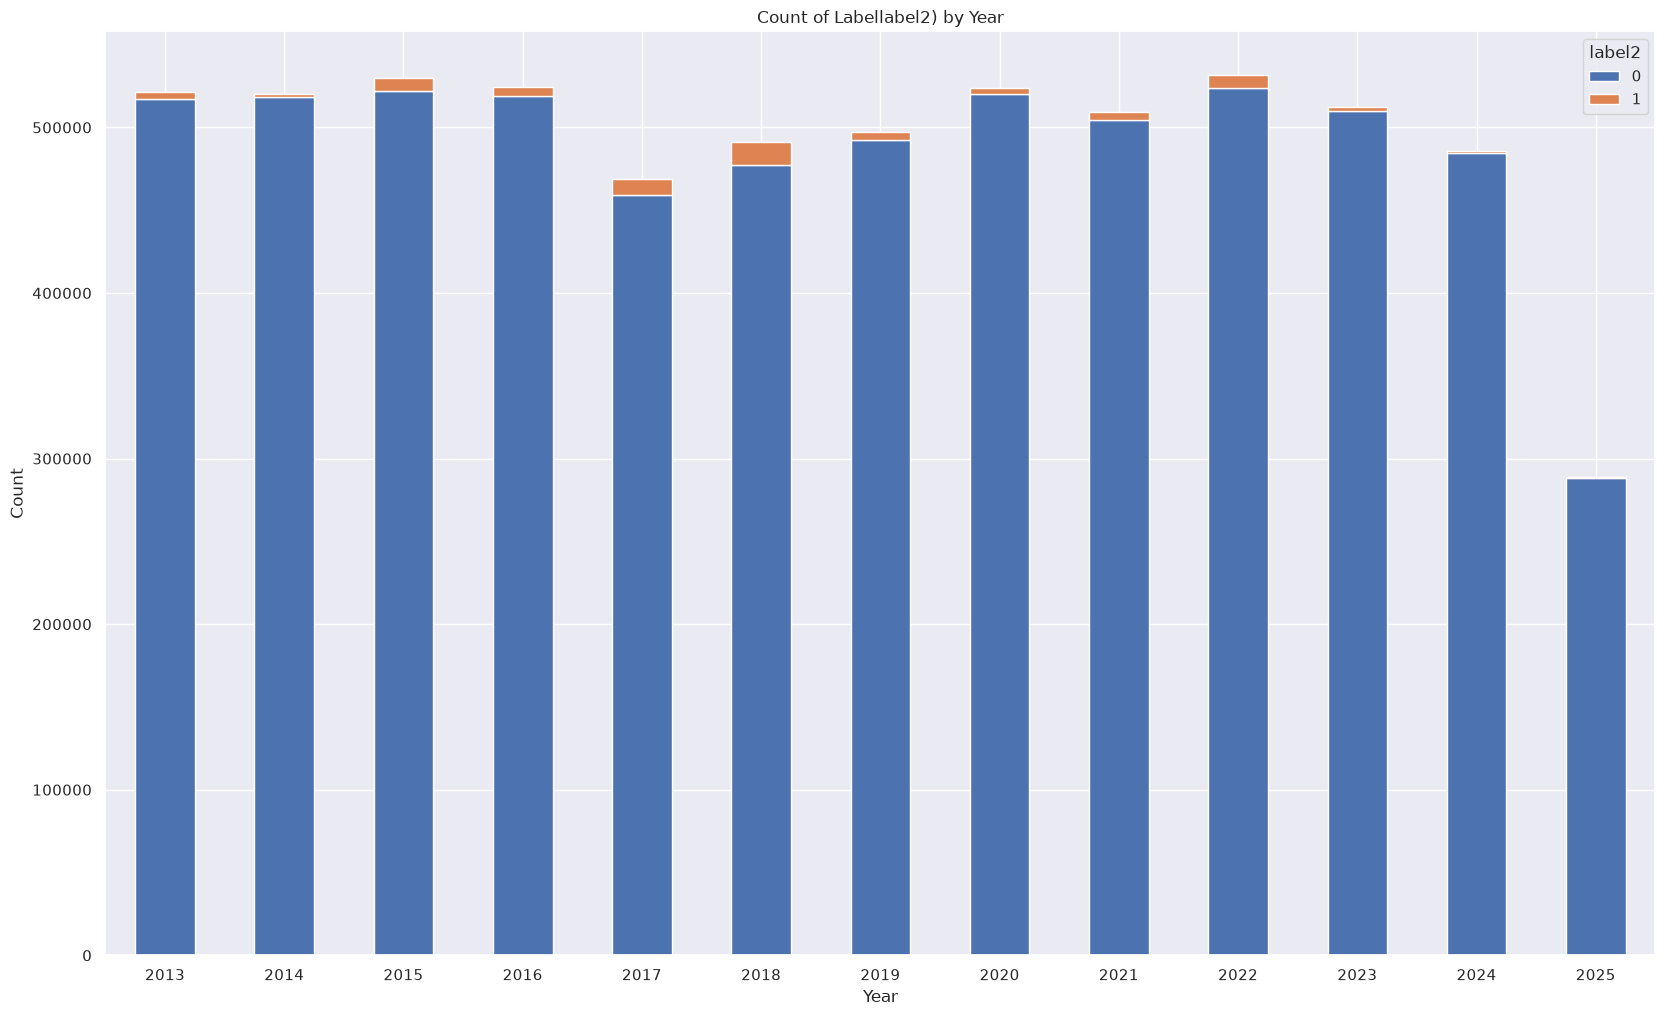

In [27]:
df_counts = pd.crosstab(df['year'], df[target])

ax = df_counts.plot(kind='bar', stacked=True, figsize=(20, 12))

plt.title(f'Count of Label{target}) by Year')
plt.xlabel('Year')
plt.ylabel('Count')

plt.xticks(rotation=0)

plt.legend(title=target)
plt.show()

In [28]:
count_df = (
    df[df[target]==1].groupby('year').size().reset_index(name="count_of_1"),
    df[df[target]==0].groupby('year').size().reset_index(name='count_of_0')
)
count_df

(    year  count_of_1
 0   2013        4204
 1   2014        1632
 2   2015        7745
 3   2016        5471
 4   2017        9843
 5   2018       14096
 6   2019        4683
 7   2020        3793
 8   2021        4760
 9   2022        7506
 10  2023        2577
 11  2024        1125
 12  2025         761,
     year  count_of_0
 0   2013      517018
 1   2014      518338
 2   2015      522276
 3   2016      519072
 4   2017      459070
 5   2018      477278
 6   2019      492563
 7   2020      520264
 8   2021      504624
 9   2022      523979
 10  2023      509846
 11  2024      484747
 12  2025      288386)